phase 4.2

In [43]:
import pandas as pd
import numpy as np
import os

from sentence_transformers import SentenceTransformer
import chromadb

df = pd.read_csv('../data/processed/cleaned_medical_notes.csv')
print(df.shape)
print(df.columns.tolist())   # confirm 'transcription' and 'medical_specialty' are here

(4951, 9)
['description', 'medical_specialty', 'sample_name', 'transcription', 'keywords', 'char_lenght', 'word_count', 'sentence_count', 'clean_text']


In [44]:
not_specialties = [
    'SOAP / Chart / Progress Notes', 'Office Notes', 'Letters',
    'Discharge Summary', 'Emergency Room Reports',
    'Consult - History and Phy.', 'IME-QME-Work Comp etc.'
]

df = df[~df['medical_specialty'].isin(not_specialties)].reset_index(drop=True)
print("rows after filtering:", len(df))
print("specialties remaining:", df['medical_specialty'].nunique())

rows after filtering: 4001
specialties remaining: 33


In [45]:
from sklearn.model_selection import train_test_split

index_df, holdout_df = train_test_split(
    df, test_size=0.05, stratify=df['medical_specialty'], random_state=42
)
index_df = index_df.reset_index(drop=True)
holdout_df = holdout_df.reset_index(drop=True)

print("index notes:", len(index_df), "| holdout queries:", len(holdout_df))

index notes: 3800 | holdout queries: 201


In [46]:
(holdout_df)

,description,medical_specialty,sample_name,transcription,keywords,char_lenght,word_count,sentence_count,clean_text
0,"Right and left heart catheterization, coronar...",Cardiovascular / Pulmonary,Heart Catheterization,"PROCEDURES:,1. Right and left heart catheteri...","cardiovascular / pulmonary, ventriculography, ...",2432,341,25,procedures right left heart catheterization co...
1,"Right ulnar nerve transposition, right carpal...",Orthopedic,Ulnar Nerve Transposition & Olecranon Bursa E...,"PREOPERATIVE DIAGNOSIS: ,1. Right cubital tu...","orthopedic, cubital tunnel syndrome, carpal tu...",2838,412,30,preoperative diagnosis right cubital tunnel sy...
2,Female referred for evaluation of an abnormal...,Obstetrics / Gynecology,OB/GYN Consultation - 1,"PAST MEDICAL HX: , Significant for asthma, pne...","obstetrics / gynecology, gravida, ecc, externa...",1750,264,24,past medical hx significant asthma pneumonia d...
3,Common CT Chest template,Cardiovascular / Pulmonary,CT Chest,"TECHNIQUE: , Sequential axial CT images were o...","cardiovascular / pulmonary, sequential axial c...",782,118,11,technique sequential axial ct images obtained ...
4,Excisional biopsy with primary closure of a 4...,Hematology - Oncology,Tongue Lesion Biopsy,"PREOPERATIVE DIAGNOSIS: , Right lateral base o...","hematology - oncology, excisional biopsy, tong...",1140,165,8,preoperative diagnosis right lateral base tong...
...,...,...,...,...,...,...,...,...,...
196,Modified Barium swallow (Deglutition Study) f...,Radiology,Deglutition Study - Modified Barium swallow,"EXAM: , Modified barium swallow.,SYMPTOM:, Dy...","radiology, aspiration, deglutition study, thin...",651,86,5,exam modified barium swallow symptom dysphagia...
197,MRI Brain - Pilocytic Astrocytoma in thalamus...,Neurology,MRI Brain - Pilocytic Astrocytoma,"CC:, Headache.,HX: ,The patient is an 8y/o RHM...","neurology, mri brain, pilocytic astrocytoma, c...",3456,516,38,cc headache hx patient rhm year history early ...
198,Small internal hemorrhoids and Ileal colonic ...,Surgery,Colonoscopy with Biopsy - 2,"PROCEDURE PERFORMED: , Colonoscopy and biopsy....","surgery, proximal transverse, transverse colon...",1928,286,11,procedure performed colonoscopy biopsy indicat...
199,Sample/template for a normal male multisystem...,General Medicine,Normal Male Exam Template,"MULTISYSTEM EXAM,CONSTITUTIONAL: ,The vital s...","general medicine, within normal limits, conjun...",1811,272,20,multisystem exam constitutional vital signs sh...


In [47]:
def chunk_text(text, chunk_size=200, overlap=20):
    words = text.split()
    chunks = []
    step = chunk_size - overlap
    for start in range(0, len(words), step):
        chunk = words[start : start + chunk_size]
        if len(chunk) == 0:
            break
        chunks.append(' '.join(chunk))
    return chunks

In [48]:
chunk_texts = []
chunk_specialties = []
chunk_note_ids = []

for note_id, row in index_df.iterrows():
    pieces = chunk_text(row['transcription'])
    for piece in pieces:
        chunk_texts.append(piece)
        chunk_specialties.append(row['medical_specialty'])
        chunk_note_ids.append(note_id)

print(f"total notes: {len(index_df)}")
print(f"total chunks: {len(chunk_texts)}")

total notes: 3800
total chunks: 11612


In [49]:
emb_path = '../data/processed/embeddings.npy'

if os.path.exists(emb_path):
    embeddings = np.load(emb_path)          # instant — load cached
    print("loaded cached embeddings:", embeddings.shape)
else:
    model = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = model.encode(chunk_texts, show_progress_bar=True, batch_size=64)
    np.save(emb_path, embeddings)           # save for next time
    print("computed and saved:", embeddings.shape)

loaded cached embeddings: (11612, 384)


In [ ]:
client = chromadb.PersistentClient(path='../data/processed/chroma_db')

existing = [c.name for c in client.list_collections()]

if "medical_notes" in existing: #use getorcreate method instead of this if else block !!!!!!!!!!!!
    # already built and saved — just reconnect (instant)
    collection = client.get_collection("medical_notes")
    print("reconnected to existing DB, count:", collection.count())
else:
    # first time only — build it
    collection = client.create_collection("medical_notes")
    all_embeddings = embeddings.tolist()
    all_metadatas  = [{"specialty": str(s), "note_id": int(n)}
                      for s, n in zip(chunk_specialties, chunk_note_ids)]
    all_ids        = [str(i) for i in range(len(chunk_texts))]
    BATCH = 5000
    for start in range(0, len(chunk_texts), BATCH):
        end = start + BATCH
        collection.add(
            embeddings=all_embeddings[start:end],
            documents=chunk_texts[start:end],
            metadatas=all_metadatas[start:end],
            ids=all_ids[start:end]
        )
        print(f"added {start} to {min(end, len(chunk_texts))}")
    print("built new DB, count:", collection.count())

reconnected to existing DB, count: 11612


pHASE 4.3 Mini Rag Classifier

In [ ]:
from collections import Counter

def classify_by_retrieval(query, k=5):
    # 1. embed the query with the SAME model (lands it in the same 384-D space)
    query_vector = model.encode([query]).tolist()

    # 2. search the store for the k most similar chunks
    results = collection.query(
        query_embeddings=query_vector,
        n_results=k
    )

    # 3. pull the specialties of those k chunks and vote
    retrieved_specialties = [m['specialty'] for m in results['metadatas'][0]]
    vote = Counter(retrieved_specialties).most_common(1)[0][0]

    return vote, retrieved_specialties

In [ ]:
test_queries = [
    "Patient has persistent cough and wheezing",
    "the patient's kidneys are not filtering properly",          # synonym: never says "renal"
    "severe chest pain radiating to the left arm",              #distance scores?? could add
    "fracture of the femur after a fall",
    "removal of the gallbladder due to stones",
    "child presents for routine vaccination and growth check",
    "patient reports feeling depressed and hopeless for weeks",
    "blurry vision and cataract in the right eye",
]

for q in test_queries:
    pred, votes = classify_by_retrieval(q, k=5)
    print(f"\nQUERY: {q}")
    print(f"  votes: {votes}")
    print(f"  → PREDICTED: {pred}")


QUERY: Patient has persistent cough and wheezing
  votes: ['Pediatrics - Neonatal', 'General Medicine', 'General Medicine', 'Cardiovascular / Pulmonary', 'General Medicine']
  → PREDICTED: General Medicine

QUERY: the patient's kidneys are not filtering properly
  votes: ['Urology', 'Nephrology', 'Nephrology', 'General Medicine', 'Nephrology']
  → PREDICTED: Nephrology

QUERY: severe chest pain radiating to the left arm
  votes: ['Cardiovascular / Pulmonary', 'Cardiovascular / Pulmonary', 'Radiology', 'General Medicine', 'General Medicine']
  → PREDICTED: Cardiovascular / Pulmonary

QUERY: fracture of the femur after a fall
  votes: ['Orthopedic', 'Surgery', 'Surgery', 'Orthopedic', 'Surgery']
  → PREDICTED: Surgery

QUERY: removal of the gallbladder due to stones
  votes: ['Gastroenterology', 'Surgery', 'Gastroenterology', 'Surgery', 'Gastroenterology']
  → PREDICTED: Gastroenterology

QUERY: child presents for routine vaccination and growth check
  votes: ['Pediatrics - Neonatal', '

In [82]:
# extreme synonym test — layperson phrasing, zero medical keywords
for q in ["my heart skips beats and races sometimes",
          "trouble breathing and a whistling sound when I exhale",
          "the bone in my lower leg snapped"]:
    pred, votes = classify_by_retrieval(q)
    print(f"\n'{q}'\n  → {pred}  {votes}")


'my heart skips beats and races sometimes'
  → Cardiovascular / Pulmonary  ['Cardiovascular / Pulmonary', 'Cardiovascular / Pulmonary', 'Cardiovascular / Pulmonary', 'Cardiovascular / Pulmonary', 'Radiology']

'trouble breathing and a whistling sound when I exhale'
  → General Medicine  ['General Medicine', 'Radiology', 'Pediatrics - Neonatal', 'General Medicine', 'Cardiovascular / Pulmonary']

'the bone in my lower leg snapped'
  → Surgery  ['Surgery', 'Orthopedic', 'Surgery', 'Orthopedic', 'Surgery']


In [83]:
pred, votes = classify_by_retrieval("Patient has persistent cough and wheezing")
print("Retrieved specialties:", votes)
print("Predicted:", pred)

# synonym test: "renal" never appears, but should retrieve kidney notes
pred, votes = classify_by_retrieval("the patient's kidneys are not filtering properly")
print("Query about kidney filtering →", pred, votes)

Retrieved specialties: ['Pediatrics - Neonatal', 'General Medicine', 'General Medicine', 'Cardiovascular / Pulmonary', 'General Medicine']
Predicted: General Medicine
Query about kidney filtering → Nephrology ['Urology', 'Nephrology', 'Nephrology', 'General Medicine', 'Nephrology']


Phase 5

Precision@K


In [84]:
def precision_at_k(query_text, true_specialty, k=5):
    qvec = model.encode([query_text]).tolist()
    results = collection.query(query_embeddings=qvec, n_results=k)
    retrieved = [m['specialty'] for m in results['metadatas'][0]]
    matches = sum(1 for s in retrieved if s == true_specialty)
    return matches / k, retrieved

precisions = []
for _, row in holdout_df.iterrows():
    p, _ = precision_at_k(row['transcription'], row['medical_specialty'])
    precisions.append(p)

print(f"Mean Precision@5: {np.mean(precisions):.2%}")
print(f"Best: {max(precisions):.0%}  Worst: {min(precisions):.0%}")

Mean Precision@5: 34.33%
Best: 100%  Worst: 0%


5.3 Retrieval Confusion Matrix

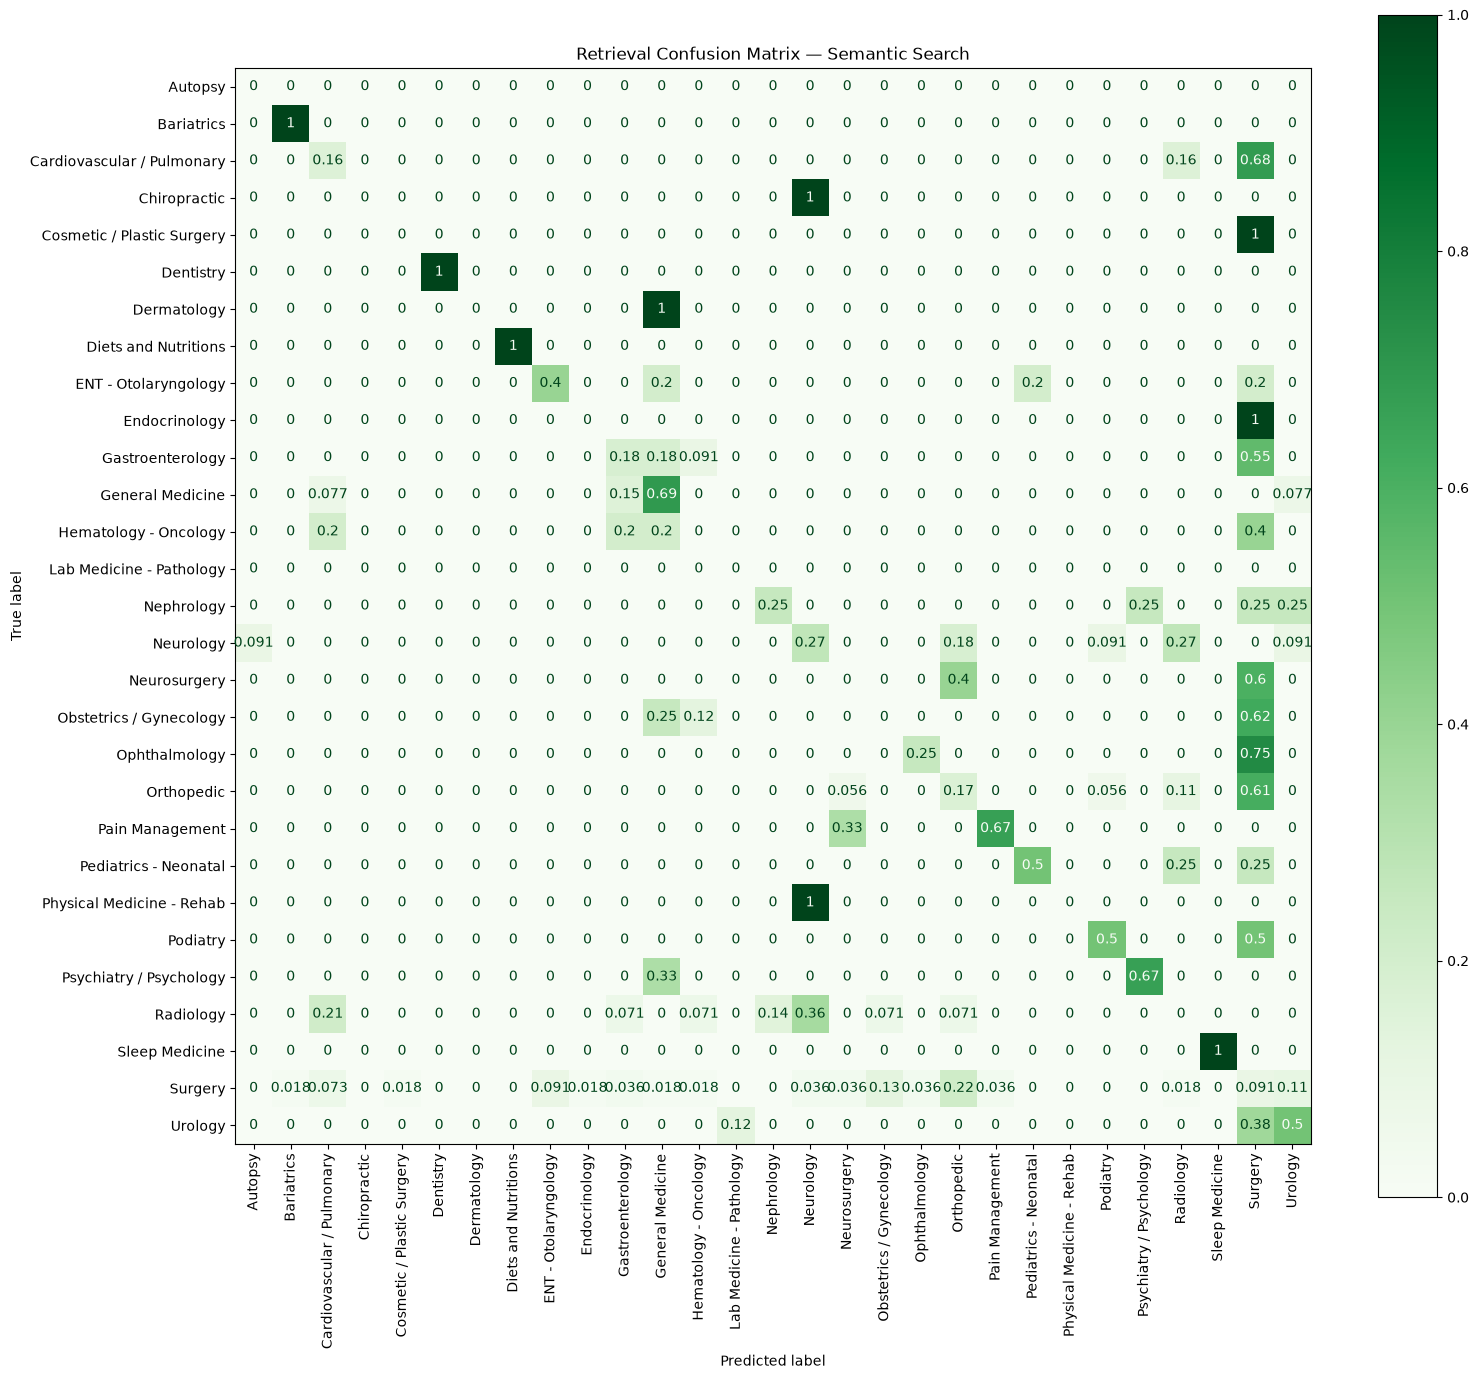

In [85]:
from collections import Counter
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

true_labels, voted_labels = [], []
for _, row in holdout_df.iterrows():
    _, retrieved = precision_at_k(row['transcription'], row['medical_specialty'])
    vote = Counter(retrieved).most_common(1)[0][0]
    true_labels.append(row['medical_specialty'])
    voted_labels.append(vote)

labels = sorted(set(true_labels) | set(voted_labels))
cm = confusion_matrix(true_labels, voted_labels, labels=labels, normalize='true')

fig, ax = plt.subplots(figsize=(16, 14))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, xticks_rotation=90, cmap='Greens')
plt.title('Retrieval Confusion Matrix — Semantic Search')
plt.tight_layout()
plt.show()

In [86]:
print("Specialties in query (holdout) set:")
print(holdout_df['medical_specialty'].value_counts())
print(f"\nQuery set covers {holdout_df['medical_specialty'].nunique()} of {df['medical_specialty'].nunique()} specialties")

Specialties in query (holdout) set:
medical_specialty
Surgery                       55
Cardiovascular / Pulmonary    19
Orthopedic                    18
Radiology                     14
General Medicine              13
Gastroenterology              11
Neurology                     11
Obstetrics / Gynecology        8
Urology                        8
Hematology - Oncology          5
Neurosurgery                   5
ENT - Otolaryngology           5
Pediatrics - Neonatal          4
Nephrology                     4
Ophthalmology                  4
Psychiatry / Psychology        3
Pain Management                3
Podiatry                       2
Dentistry                      1
Diets and Nutritions           1
Bariatrics                     1
Endocrinology                  1
Chiropractic                   1
Dermatology                    1
Sleep Medicine                 1
Physical Medicine - Rehab      1
Cosmetic / Plastic Surgery     1
Name: count, dtype: int64

Query set covers 27 of 33 sp